Successfully loaded 39154 rows from CEAS_08.csv
Training on cuda...
Epoch 1/5 | Loss: 0.1476
Epoch 2/5 | Loss: 0.0487
Epoch 3/5 | Loss: 0.0252
Epoch 4/5 | Loss: 0.0175
Epoch 5/5 | Loss: 0.0107

Accuracy: 0.9936
Recall:   0.9963
F1 Score: 0.9943


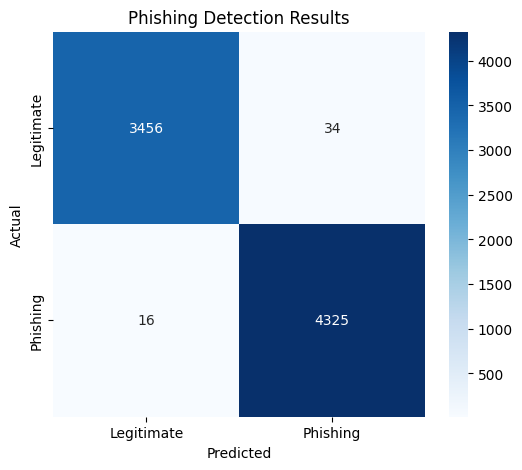

In [8]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# --- 1. DATA PREPROCESSING & DATASET ---
class PhishingDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)

    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.sequences[idx], self.labels[idx]

def get_data_loaders(file_path, text_col='body', label_col='label', max_len=100, batch_size=32):
    # Load with robust settings to ensure all data is read
    df = pd.read_csv(file_path, encoding='utf-8', on_bad_lines='skip', low_memory=False)
    print(f"Successfully loaded {len(df)} rows from {file_path}")

    # Handle missing data without dropping the whole row
    df[text_col] = df[text_col].fillna("empty_body")
    df[label_col] = pd.to_numeric(df[label_col], errors='coerce').fillna(0)

    # Tokenization & Vocab
    def clean(text): return re.sub(r'[^a-z\s]', '', str(text).lower()).split()
    tokenized = [clean(t) for t in df[text_col]]
    
    vocab = {w: i+2 for i, (w, _) in enumerate(Counter([w for t in tokenized for w in t]).most_common(10000))}
    vocab['<PAD>'], vocab['<UNK>'] = 0, 1

    # Convert to padded sequences
    seqs = [[vocab.get(w, 1) for w in t[:max_len]] + [0]*(max_len - len(t[:max_len])) for t in tokenized]
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(seqs, df[label_col].values, test_size=0.2, random_state=42)
    
    train_loader = DataLoader(PhishingDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(PhishingDataset(X_test, y_test), batch_size=batch_size)
    
    return train_loader, test_loader, len(vocab)

# --- 2. 1D-CNN ARCHITECTURE ---
class PhishingCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, num_filters=128, kernel_size=3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.conv = nn.Conv1d(embed_dim, num_filters, kernel_size)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(num_filters, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1) # [batch, embed, seq_len]
        x = torch.relu(self.conv(x))
        x = self.pool(x).squeeze(2)
        x = self.dropout(x)
        return self.sigmoid(self.fc(x))

# --- 3. TRAINING AND DETAILED EVALUATION ---
def run_pipeline(csv_file):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    train_loader, test_loader, vocab_sz = get_data_loaders(csv_file)
    model = PhishingCNN(vocab_sz).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    print(f"Training on {device}...")
    for epoch in range(5):
        model.train()
        epoch_loss = 0
        for texts, labels in train_loader:
            texts, labels = texts.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(texts)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch {epoch+1}/5 | Loss: {epoch_loss/len(train_loader):.4f}")

    # Evaluation for Metrics
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for texts, labels in test_loader:
            texts = texts.to(device)
            outputs = model(texts)
            all_preds.extend((outputs > 0.5).float().cpu().numpy())
            all_labels.extend(labels.numpy())

    # Display Metrics
    print("\n" + "="*30)
    print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
    print(f"Recall:   {recall_score(all_labels, all_preds):.4f}")
    print(f"F1 Score: {f1_score(all_labels, all_preds):.4f}")
    print("="*30)

    # Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Legitimate', 'Phishing'], 
                yticklabels=['Legitimate', 'Phishing'])
    plt.title('Phishing Detection Results')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

if __name__ == "__main__":
    # Ensure your CSV is named 'phishing.csv' or change this string
    run_pipeline('CEAS_08.csv')




